# 01 Exploratory Data Analysis

Churn rate measures the percentage of customers who stop using a product or service over a specific period, reflecting customer attrition and business retention performance.

## Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

In [2]:
print("Loading data... user_logs is large, give it 1-2 minutes")

members      = pd.read_csv("../data/members_v3.csv")
train        = pd.read_csv("../data/train_v2.csv")
transactions = pd.read_csv("../data/transactions_v2.csv")
user_logs    = pd.read_csv("../data/user_logs_v2.csv")

print(f"members:      {members.shape}")
print(f"train:        {train.shape}")
print(f"transactions: {transactions.shape}")
print(f"user_logs:    {user_logs.shape}")

Loading data... user_logs is large, give it 1-2 minutes
members:      (6769473, 6)
train:        (970960, 2)
transactions: (1431009, 9)
user_logs:    (18396362, 9)


In [3]:
print("=== MEMBERS ===")
display(members.head())

print("\n=== TRAIN ===")
display(train.head())

print("\n=== TRANSACTIONS ===")
display(transactions.head())

print("\n=== USER LOGS ===")
display(user_logs.head())

=== MEMBERS ===


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915



=== TRAIN ===


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1



=== TRANSACTIONS ===


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0
3,+/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=,36,30,180,180,1,20170329,20170331,1
4,+00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=,41,30,99,99,1,20170323,20170423,0



=== USER LOGS ===


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,7100.454
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,28401.558


## Data Aggregation and Merging into one dataset

In [4]:
# Problem: user_logs has one row per user per day
#   e.g. UserA has 300 rows (one for each day they were active)
#   But our model needs one row per user to predict one churn outcome
#
# Solution: groupby msno (user ID) and collapse all daily rows
# into a single summary row using aggregation functions (mean, count)
#
# Do we lose data? Yes - we lose daily granularity (what happened on Jan 1st)
#   But we keep behavioral patterns (averages over time)
#   which is what actually predicts churn
#   We don't care that UserA listened 3000 seconds on one specific day
#   We care that UserA listens 3000 seconds on average which is the signal
#
# What each new column means:
#   avg_num_25     → avg songs user only listened to 25% of = songs they skipped quickly
#                    high value = user is not finding music they like = churn risk
#   avg_num_50     → avg songs listened to roughly halfway through
#   avg_num_75     → avg songs listened to 3/4 of the way
#   avg_num_985    → avg songs listened to almost full completion
#   avg_num_100    → avg songs fully completed = most important engagement signal
#                    high value = user enjoys the platform and finds good music
#   avg_num_unq    → avg unique songs per session = variety of listening habits
#   avg_total_secs → avg total seconds of music played per day = overall engagement
#                    usually churned users will have much lower values here
#   total_days_active → count of how many rows (days) this user appears in logs
#                    = how many days they were active on the platform
#                    because user_logs is one row per day, counting rows = counting days
#
# .reset_index() moves msno back to a regular column
#   groupby() makes msno the index by default
#   we need it as a regular column so we can merge on it later
# ============================================================

print("Aggregating user_logs... (may take 1-2 mins)")

user_agg = user_logs.groupby('msno').agg(
    avg_num_25        = ('num_25',     'mean'),
    avg_num_50        = ('num_50',     'mean'),
    avg_num_75        = ('num_75',     'mean'),
    avg_num_985       = ('num_985',    'mean'),
    avg_num_100       = ('num_100',    'mean'),
    avg_num_unq       = ('num_unq',    'mean'),
    avg_total_secs    = ('total_secs', 'mean'),
    total_days_active = ('date',       'count')
).reset_index()

print(f"Before aggregation: {user_logs.shape[0]:,} rows (one per user per day)")
print(f"After aggregation:  {user_agg.shape[0]:,} rows (one per user)")
print(f"Collapsed {user_logs.shape[0] - user_agg.shape[0]:,} rows into summaries")
display(user_agg.head())

Aggregating user_logs... (may take 1-2 mins)
Before aggregation: 18,396,362 rows (one per user per day)
After aggregation:  1,103,894 rows (one per user)
Collapsed 17,292,468 rows into summaries


,msno,avg_num_25,avg_num_50,avg_num_75,avg_num_985,avg_num_100,avg_num_unq,avg_total_secs,total_days_active
0,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,3.307692,0.423077,0.384615,0.192308,18.153846,20.384615,4534.900962,26
1,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,6.161290,2.903226,2.419355,4.645161,19.000000,28.548387,6210.577161,31
2,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,1.535714,0.428571,0.535714,0.428571,17.321429,16.714286,4121.830714,28
3,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,9.857143,7.761905,4.761905,3.047619,20.761905,39.428571,7137.931333,21
4,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,3.620690,0.827586,1.344828,1.206897,16.517241,7.931034,4014.939552,29


In [5]:
# Same problem as user_logs so there is one row per transaction event
#   A loyal user subscribed for 2 years has ~24 rows (one per monthly payment)
#   We need one row per user
#
# What each new column means:
#   total_transactions  → how many payments this user has made in total
#                         more transactions = longer customer = less likely to churn
#   total_cancels       → how many times the user actively cancelled their subscription
#                         NOTE: cancelling does not always mean churned
#                         users cancel and re-subscribe all the time (e.g. changing plan)
#                         but a high number of cancels is a churn risk signal
#                         we use sum here because we want the total count not average
#   avg_plan_days       → average subscription length they buy (30 days vs 365 days)
#                         users who buy longer plans are more committed = less likely to churn
#   avg_list_price      → what the subscription plan normally costs (NTD currency)
#   avg_amount_paid     → what they actually paid on average
#                         if avg_amount_paid < avg_list_price = they received discounts
#                         we'll use this gap in feature engineering in 02_feature.ipynb
#   auto_renew_rate     → proportion of transactions where auto-renew was on
#                         mean of a 0/1 column gives us a proportion (e.g. 0.8 = 80% of time)
#                         auto-renew on = passive renewal = much less likely to churn
#   last_payment_method → their most recent payment method ID
#                         some payment methods (e.g. credit card) correlate with
#                         lower churn than others (e.g. prepaid vouchers)
#                         we use 'last' to get the most recent one, not a mean
# ============================================================

trans_agg = transactions.groupby('msno').agg(
    total_transactions  = ('payment_method_id', 'count'),
    total_cancels       = ('is_cancel',          'sum'),
    avg_plan_days       = ('payment_plan_days',   'mean'),
    avg_list_price      = ('plan_list_price',     'mean'),
    avg_amount_paid     = ('actual_amount_paid',  'mean'),
    auto_renew_rate     = ('is_auto_renew',       'mean'),
    last_payment_method = ('payment_method_id',   'last')
).reset_index()

print(f"Before aggregation: {transactions.shape[0]:,} rows (one per transaction)")
print(f"After aggregation:  {trans_agg.shape[0]:,} rows (one per user)")
display(trans_agg.head())

Before aggregation: 1,431,009 rows (one per transaction)
After aggregation:  1,197,050 rows (one per user)


,msno,total_transactions,total_cancels,avg_plan_days,avg_list_price,avg_amount_paid,auto_renew_rate,last_payment_method
0,+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=,1,0,395.0,1599.0,1599.0,0.0,22
1,+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=,1,0,30.0,99.0,99.0,1.0,41
2,+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=,2,0,30.0,149.0,149.0,1.0,39
3,+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=,1,0,30.0,149.0,149.0,1.0,41
4,++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=,1,0,30.0,149.0,149.0,1.0,41


In [6]:
# Now that every table has one row per user, we can merge them by matching rows using msno
#
# We start with train because that has our target variable (is_churn)
# Every user in train must stay in our final dataset
# Then we attach their demographics, transaction history, and listening habits
#
# how='left' means: keep all rows from the left table (train)
#   even if there is no matching msno in the right table
#   if a user has no listening logs, they still stay in the dataset
#   their listening columns will just be NaN (we fix this in Cell 7)
#
# Merge order:
#   train (churn labels) + members (demographics) → add city, age, gender
#   + trans_agg (payment history)                  → add cancel history, plan info
#   + user_agg (listening behavior)                → add engagement signals
# ============================================================

df = train.merge(members,   on='msno', how='left')
df = df.merge(trans_agg,    on='msno', how='left')
df = df.merge(user_agg,     on='msno', how='left')

# save the raw merged dataset before any cleaning
# this is useful if we ever want to go back to the original merged state
# without re-running all the aggregation and merge steps again
df.to_csv('../data/merged_datasets/merged_raw.csv', index=False)
print("Saved merged_raw.csv in data/merged_datasets folder")


print(f"Final merged shape: {df.shape}")
print(f"Total columns: {len(df.columns)}")
print(f"Columns: {list(df.columns)}")
display(df.head(3))

Saved merged_raw.csv in data/merged_datasets folder
Final merged shape: (970960, 22)
Total columns: 22
Columns: ['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'total_transactions', 'total_cancels', 'avg_plan_days', 'avg_list_price', 'avg_amount_paid', 'auto_renew_rate', 'last_payment_method', 'avg_num_25', 'avg_num_50', 'avg_num_75', 'avg_num_985', 'avg_num_100', 'avg_num_unq', 'avg_total_secs', 'total_days_active']


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,total_transactions,total_cancels,avg_plan_days,...,auto_renew_rate,last_payment_method,avg_num_25,avg_num_50,avg_num_75,avg_num_985,avg_num_100,avg_num_unq,avg_total_secs,total_days_active
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,20131223.0,NaN,NaN,NaN,...,NaN,NaN,16.909091,2.090909,1.181818,0.909091,28.909091,31.636364,7327.141545,11.0
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,20131223.0,1.0,0.0,30.0,...,0.0,36.0,0.000000,0.666667,0.333333,0.000000,4.333333,5.000000,1164.418167,6.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,20131227.0,2.0,0.0,75.0,...,0.0,15.0,11.950000,2.850000,1.600000,1.100000,10.250000,21.600000,3390.523350,20.0


## Data Cleaning - Exploration

- As a general step before cleaning, we need to check for missing values, outliers and identify any extreme or out of place values
- Lets check for data type as well and make sure it makes sense for the full merged dataset

In [7]:
# We need a pre-cleaning explanation
# Before fixing anything we need to understand what we are dealing with
# This is standard practice since cleaning blindly leads to losing valuable information
# We check 3 things:
#   1. Data types - is each column the right type?
#   2. Null values - which columns have missing data and how much?
#   3. Basic stats - are there any obviously wrong values (like age = -7000)?
# ============================================================

# 1. Check data types of every column
print("=== DATA TYPES ===")
print(df.dtypes)
print()

# 2. Check null values - how many missing values per column
print("=== NULL VALUES ===")
null_counts = df.isnull().sum()
null_pct    = (df.isnull().sum() / len(df) * 100).round(2)
null_df     = pd.DataFrame({
    'null_count' : null_counts,
    'null_%'     : null_pct
}).sort_values('null_%', ascending=False)

# only show columns that actually have nulls
null_df_filtered = null_df[null_df['null_count'] > 0]
if len(null_df_filtered) == 0:
    print("No null values found")
else:
    print(null_df_filtered.to_string())
print()

# 3. Basic statistics - min, max, mean, std for every numeric column
# this is where we spot things like age = -7000 or age = 2016
print("=== BASIC STATISTICS ===")
print(df.describe().round(2).to_string())

=== DATA TYPES ===
msno                       object
is_churn                    int64
city                      float64
bd                        float64
gender                     object
registered_via            float64
registration_init_time    float64
total_transactions        float64
total_cancels             float64
avg_plan_days             float64
avg_list_price            float64
avg_amount_paid           float64
auto_renew_rate           float64
last_payment_method       float64
avg_num_25                float64
avg_num_50                float64
avg_num_75                float64
avg_num_985               float64
avg_num_100               float64
avg_num_unq               float64
avg_total_secs            float64
total_days_active         float64
dtype: object

=== NULL VALUES ===
                        null_count  null_%
gender                      582055   59.95
total_days_active           216409   22.29
avg_num_25                  216409   22.29
avg_total_secs            

### What the inspection told us & what we do about it

#### 1. `bd` (age) has extreme outliers

- **What we saw:** min = -3152, max = 2016, median = 0 meaning most values are 0
- **What we do:** rename to `age`, replace 0, negatives, and over 100 with NaN
- **Visualization:** box plot before and after

#### 2. `gender` are 59.95% missing

- **What we saw:** 582,055 nulls so more than half the dataset has no gender
- **What we do:** fill NaN with `'unknown'` so it becomes its own category, we don't drop these users
- **Visualization:** bar chart before and after showing the 3 categories

#### 3. User log columns are 22.29% missing
- **What we saw:** all 8 listening columns (avg_num_25, avg_total_secs etc.) have exactly 216,409 nulls so the same number, meaning these are the same users who simply had no listening activity recorded
- **What we do:** fill with median of each column
- **No visualization needed** => just confirm nulls are gone after

#### 4. Member columns are 11.33% missing
- **What we saw:** city, bd, registered_via, registration_init_time all have exactly 109,993 nulls so its the same users, meaning these users had no record in members.csv at all
- **What we do:** fill numeric ones with median
- **No visualization needed**

#### 5. Transaction columns are 3.85% missing
- **What we saw:** all 7 transaction columns have exactly 37,382 nulls so the same users who had no transaction history
- **What we do:** fill with median
- **No visualization needed**

#### 6. Data types are mostly fine
- **What we saw:** everything is float64 or object which is correct for our use case. No fixes needed here.

#### Summary of cells to write

| Cell | What it does | Visualization |
|---|---|---|
| 7a | Box plot age before | `plot_age_boxplot_before.png` |
| 7b | Bar chart gender before | `plot_gender_before.png` |
| 7c | Clean age (rename, remove outliers) | — |
| 7d | Box plot age after | `plot_age_boxplot_after.png` |
| 7e | Clean gender (fill unknown) | — |
| 7f | Bar chart gender after | `plot_gender_after.png` |
| 7g | Fill all remaining nulls with median | — |
| 7h | Confirm zero nulls remain | — |

We generate before/after pair visualizations for age and gender for the presentation. The rest of the nulls are handled silently with median imputation therefore, no visualization needed because there's nothing interesting to show, just missing numbers being filled.

In [8]:
# Age before cleaning
# From our pre-cleaning inspection we saw:
#   min = -3152  → impossible, clearly garbage entry
#   max = 2016   → user typed birth year instead of age
#   mean = 13.58 → dragged down by the massive amount of 0s
#   50% = 0      → median is 0 meaning more than half the values are 0
# We visualise the raw distribution to show how extreme this is using a box-whisker plot
# ============================================================

print("=== AGE (bd) column - before cleaning ===")
print(f"Min value:              {df['bd'].min()}")
print(f"Max value:              {df['bd'].max()}")
print(f"Zero values:            {(df['bd'] == 0).sum():,}  ← users who skipped age field")
print(f"Negative values:        {(df['bd'] < 0).sum():,}  ← impossible")
print(f"Over 100:               {(df['bd'] > 100).sum():,}  ← likely typed birth year instead of age")
print(f"Valid range (1-100):    {((df['bd'] > 0) & (df['bd'] <= 100)).sum():,}")
print(f"Total rows:             {len(df):,}")

=== AGE (bd) column - before cleaning ===
Min value:              -3152.0
Max value:              2016.0
Zero values:            473,729  ← users who skipped age field
Negative values:        69  ← impossible
Over 100:               454  ← likely typed birth year instead of age
Valid range (1-100):    386,715
Total rows:             970,960


The bd variable as explained by the kaggle description is the age of the user which they entered when they created there account, an explanatory data analysis of the feature explains the following:
```
Zero values:  4,540,215  ← most users just skipped the age field at registration
Max value:    2016        ← some users may have typed their birth year instead of their age but we cannot guarantee that.
Negative:     274         ← garbage entries
Valid (1-100): 2,223,607  ← only ~33% of users have a real age value
```

So the column is age, it's just that:
- Most users never filled it in (left it 0 or blank)
- Some users misunderstood the field and typed `1995` meaning born in 1995, not age 1995
- A tiny number entered complete nonsense

This shows that **real world data is messy.** The following cleaning handles all of it correctly:

```python
df['age'] = df['age'].replace(0, np.nan)      # removes the 4.5M blanks
df.loc[df['age'] < 0,   'age'] = np.nan       # removes the 274 negatives
df.loc[df['age'] > 100, 'age'] = np.nan       # removes the birth year mistakes
```

After cleaning, age will have lots of NaN which we then fill with the median and that's fine and expected. The model just treats age as a feature where most users are unknown, which is realistic.

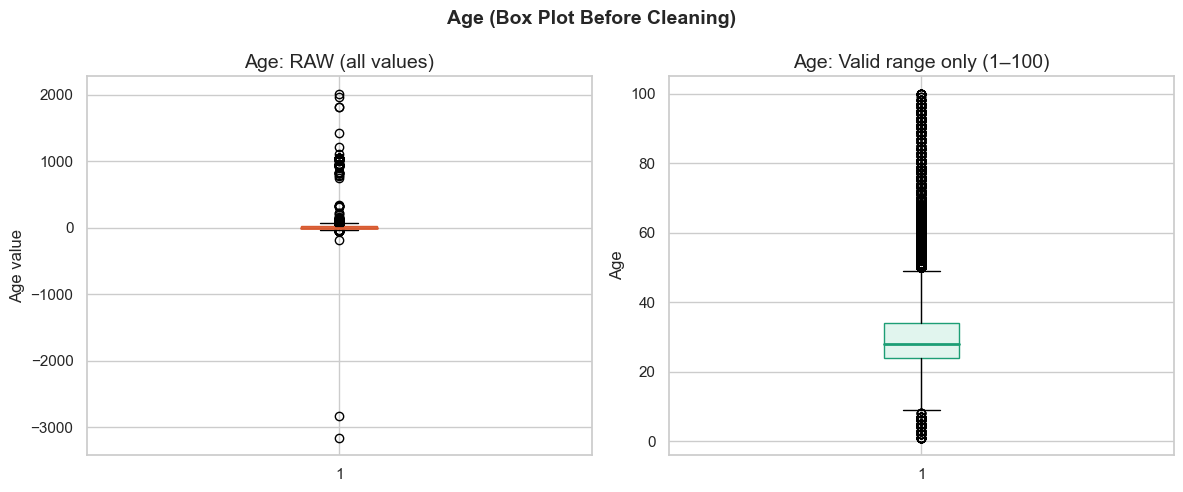

In [9]:
# box and whisker plot to show age outliers before cleaning
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: raw data - shows how extreme the outliers are
axes[0].boxplot(df['bd'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#FAECE7', color='#D85A30'),
                medianprops=dict(color='#D85A30', linewidth=2))
axes[0].set_title('Age: RAW (all values)')
axes[0].set_ylabel('Age value')

# right: valid range only (1-100)
df_valid = df[(df['bd'] > 0) & (df['bd'] <= 100)]['bd']
axes[1].boxplot(df_valid, patch_artist=True,
                boxprops=dict(facecolor='#E1F5EE', color='#1D9E75'),
                medianprops=dict(color='#1D9E75', linewidth=2))
axes[1].set_title('Age: Valid range only (1–100)')
axes[1].set_ylabel('Age')

plt.suptitle('Age (Box Plot Before Cleaning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_age_boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# gender column before cleaning
# From our pre-cleaning inspection we also saw:

# We visualise the raw distribution to show how extreme this is using a box-whisker plot
# ============================================================

print("=== AGE (bd) column - before cleaning ===")
print(f"Min value:              {df['bd'].min()}")
print(f"Max value:              {df['bd'].max()}")
print(f"Zero values:            {(df['bd'] == 0).sum():,}  ← users who skipped age field")
print(f"Negative values:        {(df['bd'] < 0).sum():,}  ← impossible")
print(f"Over 100:               {(df['bd'] > 100).sum():,}  ← likely typed birth year instead of age")
print(f"Valid range (1-100):    {((df['bd'] > 0) & (df['bd'] <= 100)).sum():,}")
print(f"Total rows:             {len(df):,}")

=== AGE (bd) column - before cleaning ===
Min value:              -3152.0
Max value:              2016.0
Zero values:            473,729  ← users who skipped age field
Negative values:        69  ← impossible
Over 100:               454  ← likely typed birth year instead of age
Valid range (1-100):    386,715
Total rows:             970,960


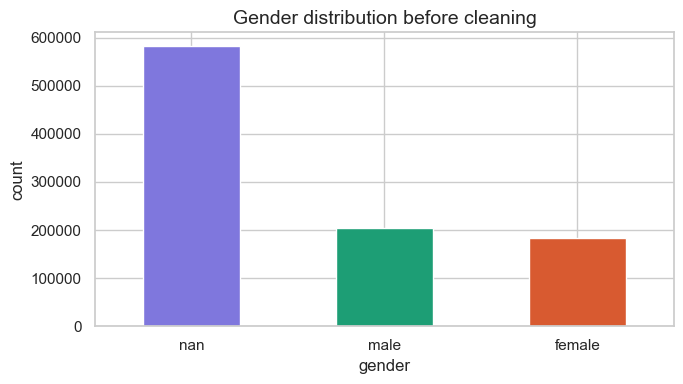

gender
NaN       582055
male      204561
female    184344
Name: count, dtype: int64

missing gender: 582,055 (59.9%)


In [11]:
# bar chart to show gender distribution before cleaning
# we can see how many nulls exist as a category

gender_before = df['gender'].value_counts(dropna=False)

plt.figure(figsize=(7, 4))
gender_before.plot(kind='bar', color=['#7F77DD', '#1D9E75', '#D85A30'], edgecolor='white', rot=0)
plt.title('Gender distribution before cleaning')
plt.ylabel('count')
plt.xlabel('gender')
plt.tight_layout()
plt.savefig('../Visualizations/plot_gender_before.png', dpi=150, bbox_inches='tight')
plt.show()

print(gender_before)
print(f"\nmissing gender: {df['gender'].isnull().sum():,} ({df['gender'].isnull().mean()*100:.1f}%)")

### Data Cleaning - Implementation

In [12]:
# rename bd to age since bd is not meaningful
# then remove all impossible values by replacing them with NaN
# NaN just means missing in pandas, we fill it with median later

df = df.rename(columns={'bd': 'age'})

df['age'] = df['age'].replace(0, np.nan)       # 0 means the user left the field blank
df.loc[df['age'] < 0,   'age'] = np.nan        # negative ages are impossible
df.loc[df['age'] > 100, 'age'] = np.nan        # values over 100 are birth years not ages

print("Age Cleaning Done")
print(f"Valid age values remaining: {df['age'].notna().sum():,}")
print(f"NaN after cleaning: {df['age'].isna().sum():,}")
print(df['age'])

Age Cleaning Done
Valid age values remaining: 386,715
NaN after cleaning: 584,245
0         28.0
1         20.0
2         18.0
3          NaN
4         35.0
          ... 
970955    28.0
970956     NaN
970957     NaN
970958    25.0
970959     NaN
Name: age, Length: 970960, dtype: float64


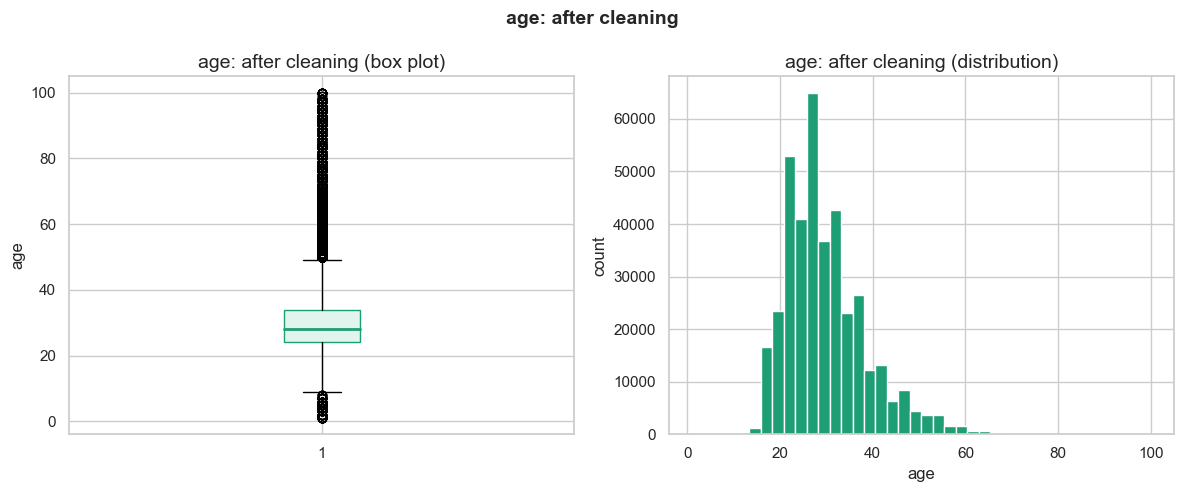

min age:  1.0
max age:  100.0
mean age: 29.9
median age: 28.0


In [13]:
# box plot after cleaning to compare with the before plot
# the distribution should now look like a realistic age curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: box plot of cleaned age
axes[0].boxplot(df['age'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#E1F5EE', color='#1D9E75'),
                medianprops=dict(color='#1D9E75', linewidth=2))
axes[0].set_title('age: after cleaning (box plot)')
axes[0].set_ylabel('age')

# right: histogram of cleaned age to show the distribution shape
axes[1].hist(df['age'].dropna(), bins=40, color='#1D9E75', edgecolor='white')
axes[1].set_title('age: after cleaning (distribution)')
axes[1].set_xlabel('age')
axes[1].set_ylabel('count')

plt.suptitle('age: after cleaning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_age_boxplot_after.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"min age:  {df['age'].min()}")
print(f"max age:  {df['age'].max()}")
print(f"mean age: {df['age'].mean():.1f}")
print(f"median age: {df['age'].median():.1f}")

In [14]:
# Fill missing gender with 'unknown' so it becomes its own category
# We do not drop these users because 60% of the dataset would be lost
# Unknown is a valid category - it just means the user did not provide gender

df['gender'] = df['gender'].fillna('unknown')

print("gender cleaning done")
print(df['gender'].value_counts())

gender cleaning done
gender
unknown    582055
male       204561
female     184344
Name: count, dtype: int64


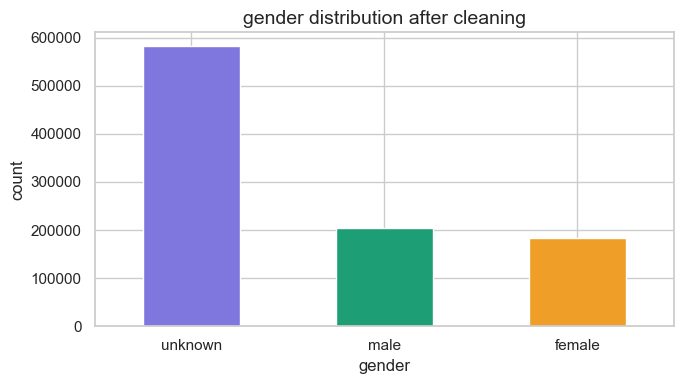

gender
unknown    582055
male       204561
female     184344
Name: count, dtype: int64

missing gender after cleaning: 0


In [15]:
# bar chart after cleaning to compare with the before plot
# we should now see 3 clean categories: male, female, unknown

gender_after = df['gender'].value_counts(dropna=False)

plt.figure(figsize=(7, 4))
gender_after.plot(kind='bar', color=['#7F77DD', '#1D9E75', '#EF9F27'], edgecolor='white', rot=0)
plt.title('gender distribution after cleaning')
plt.ylabel('count')
plt.xlabel('gender')
plt.tight_layout()
plt.savefig('../Visualizations/plot_gender_after.png', dpi=150, bbox_inches='tight')
plt.show()

print(gender_after)
print(f"\nmissing gender after cleaning: {df['gender'].isnull().sum()}")

#### Fill all remaining numeric nulls with the median of each column


In [16]:
# These nulls came from users who had no matching rows in members, 
# Transactions, or user_logs after the left merge
# We use median instead of mean because median is not affected by outliers
# This is called median imputation and is a standard cleaning technique

num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("median imputation done")
print(f"dataset shape: {df.shape}")

median imputation done
dataset shape: (970960, 22)


#### Final check to confirm the dataset is fully clean


In [17]:
# we expect zero nulls across all columns at this point

remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if len(remaining_nulls) == 0:
    print("dataset is fully clean: no nulls remaining")
else:
    print("nulls still remaining:")
    print(remaining_nulls)

print(f"\nfinal dataset shape: {df.shape}")
print(f"total columns: {len(df.columns)}")

dataset is fully clean: no nulls remaining

final dataset shape: (970960, 22)
total columns: 22


## Generating EDA Charts

EDA Chart 1 - What is the overall churn rate?

Churn rate measures the percentage of customers who stop using a product or service over a specific period, reflecting customer attrition and business retention performance.

This is the most important baseline number for the whole project
- churn rate = proportion of users who churned = mean of the is_churn column
- if churn is rare (under 10%) the dataset is imbalanced which affects modeling

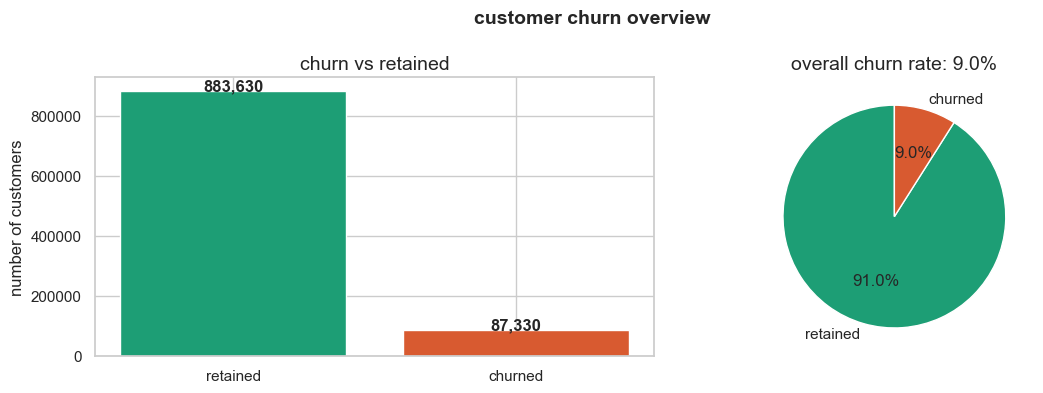

churn rate: 9.0%


In [18]:
churn_counts = df['is_churn'].value_counts()
churn_rate   = df['is_churn'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart showing absolute numbers
axes[0].bar(['retained', 'churned'], churn_counts.values,
            color=['#1D9E75', '#D85A30'], edgecolor='white')
axes[0].set_title('churn vs retained')
axes[0].set_ylabel('number of customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# pie chart showing percentage split
axes[1].pie(churn_counts.values, labels=['retained', 'churned'],
            colors=['#1D9E75', '#D85A30'], autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'overall churn rate: {churn_rate:.1f}%')

plt.suptitle('customer churn overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"churn rate: {churn_rate:.1f}%")

The overall churn rate is approximately 9%, meaning the dataset is imbalanced:

- 91% of users are retained and only 9% churned. 
- This is important because a naive model could achieve 91% accuracy by simply predicting "retained" for everyone, which is useless. 
- In notebook 03_modeling.ipynb we will handle this problem.

EDA Chart 2 - Churn rate per city to see if location affects churn

- Some cities may have worse retention than others
- This is useful for business decisions around location-based campaigns

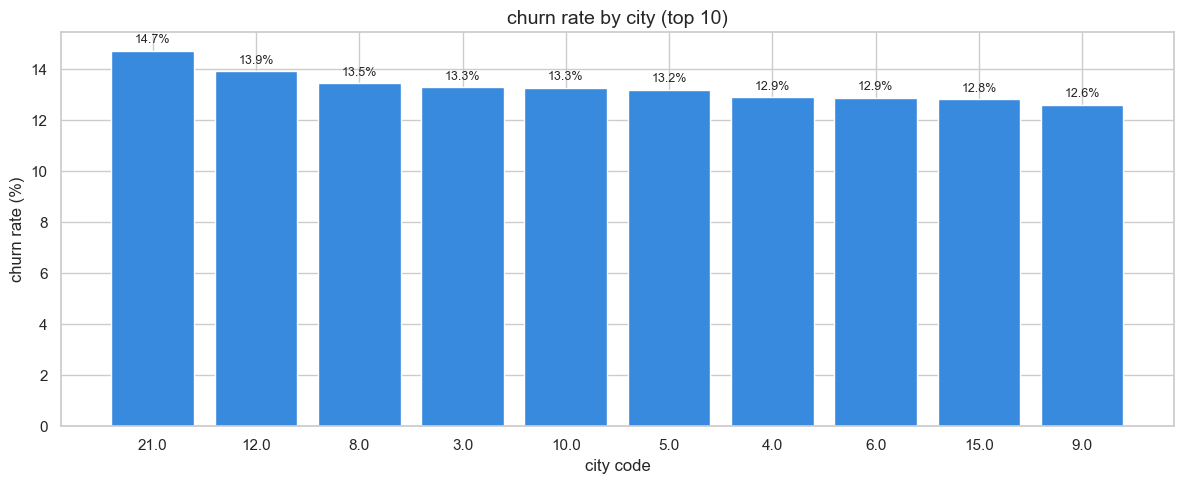

In [19]:
city_churn = df.groupby('city')['is_churn'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
bars = plt.bar(city_churn.index.astype(str), city_churn.values * 100,
               color='#378ADD', edgecolor='white')
plt.title('churn rate by city (top 10)')
plt.xlabel('city code')
plt.ylabel('churn rate (%)')

for bar, val in zip(bars, city_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val*100:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../Visualizations/plot_churn_by_city.png', dpi=150, bbox_inches='tight')
plt.show()

EDA Chart 3 - Churn rate per gender group

- We have 3 categories now: male, female, unknown
- This chart also feeds into our bias analysis in notebook 03_modeling.ipynb
- If the model predicts differently for male vs female that could be a fairness issue

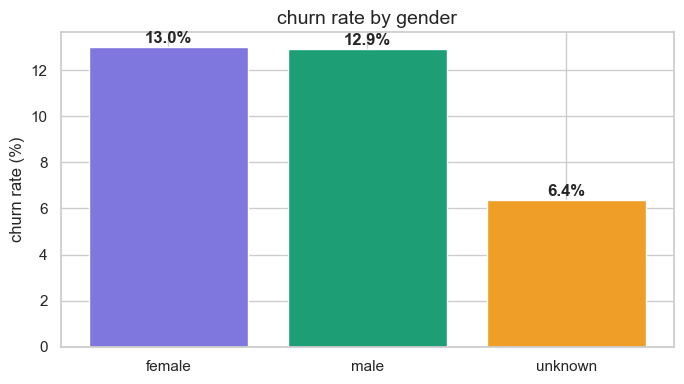

In [20]:
gender_churn = df.groupby('gender')['is_churn'].mean() * 100

plt.figure(figsize=(7, 4))
bars = plt.bar(gender_churn.index, gender_churn.values,
               color=['#7F77DD', '#1D9E75', '#EF9F27'], edgecolor='white')
plt.title('churn rate by gender')
plt.ylabel('churn rate (%)')

for bar, val in zip(bars, gender_churn.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_churn_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

EDA Chart 4 - Do churned users listen less? **This is the core hypothesis of this project**
- if yes, it means we can detect churn risk from listening patterns
- before the user actually cancels and that is the business value

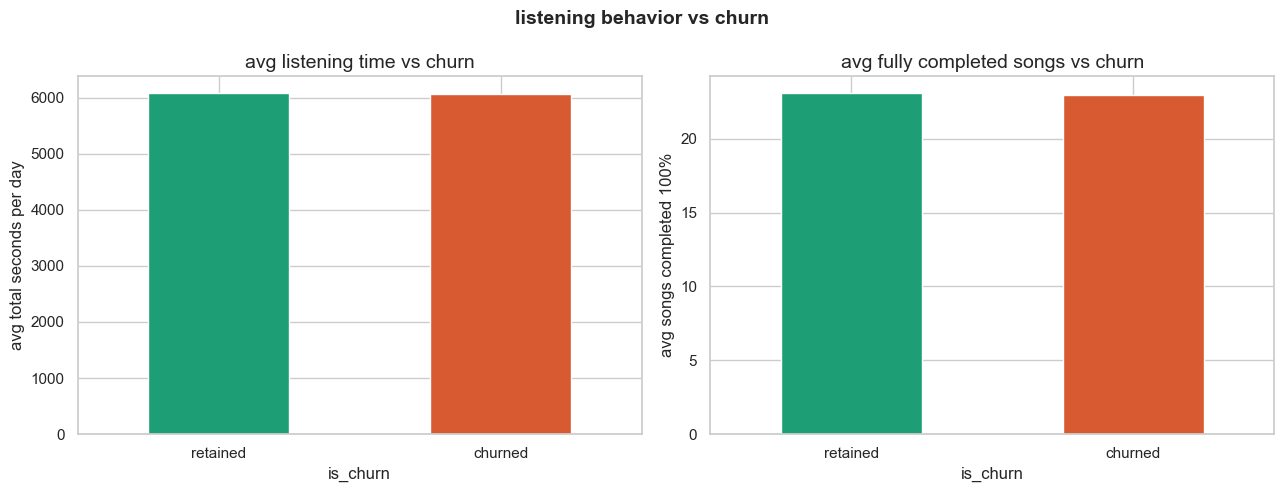

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# average total seconds listened per day
df.groupby('is_churn')['avg_total_secs'].mean().plot(
    kind='bar', ax=axes[0], color=['#1D9E75', '#D85A30'],
    edgecolor='white', rot=0)
axes[0].set_title('avg listening time vs churn')
axes[0].set_xticklabels(['retained', 'churned'])
axes[0].set_ylabel('avg total seconds per day')

# average fully completed songs per session
df.groupby('is_churn')['avg_num_100'].mean().plot(
    kind='bar', ax=axes[1], color=['#1D9E75', '#D85A30'],
    edgecolor='white', rot=0)
axes[1].set_title('avg fully completed songs vs churn')
axes[1].set_xticklabels(['retained', 'churned'])
axes[1].set_ylabel('avg songs completed 100%')

plt.suptitle('listening behavior vs churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/plot_listening_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

EDA Chart 5 - Do users who cancel a lot end up churning more?

- Remember: cancelling a subscription is not the same as churning
- A user can cancel and re-subscribe immediately (e.g. changing plans)
- but repeated cancels may signal dissatisfaction

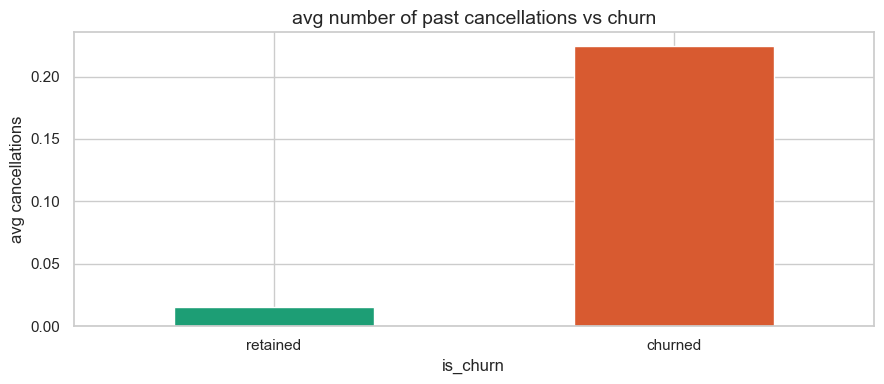

In [22]:
plt.figure(figsize=(9, 4))
df.groupby('is_churn')['total_cancels'].mean().plot(
    kind='bar', color=['#1D9E75', '#D85A30'], edgecolor='white', rot=0)
plt.title('avg number of past cancellations vs churn')
plt.xticks([0, 1], ['retained', 'churned'])
plt.ylabel('avg cancellations')
plt.tight_layout()
plt.savefig('../Visualizations/plot_cancels_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

EDA Chart 6 - does auto renew affect churn?

- users with auto_renew=on renew passively without taking any action
- we expect users with low auto renew rate to churn more
- this is one of the strongest signals in the dataset
- auto_renew_rate is a proportion so 1.0 means always auto renews, 0.0 means never
- users who never set auto renew have to manually renew each month which is an indication of a higher churn risk

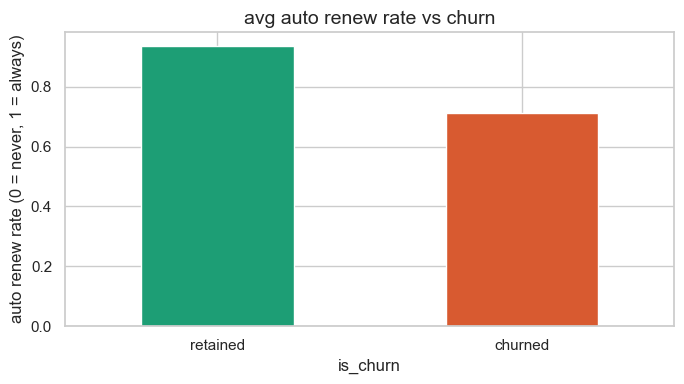

In [23]:
plt.figure(figsize=(7, 4))
df.groupby('is_churn')['auto_renew_rate'].mean().plot(
    kind='bar', color=['#1D9E75', '#D85A30'], edgecolor='white', rot=0)
plt.title('avg auto renew rate vs churn')
plt.xticks([0, 1], ['retained', 'churned'])
plt.ylabel('auto renew rate (0 = never, 1 = always)')
plt.tight_layout()
plt.savefig('../Visualizations/plot_autorenew_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

EDA Chart 7 - correlation heatmap

- shows how every numeric feature relates to every other feature
- values close to 1 or -1 mean strong relationship, close to 0 means weak
- we look at the is_churn row specifically to see which features are most related to churn

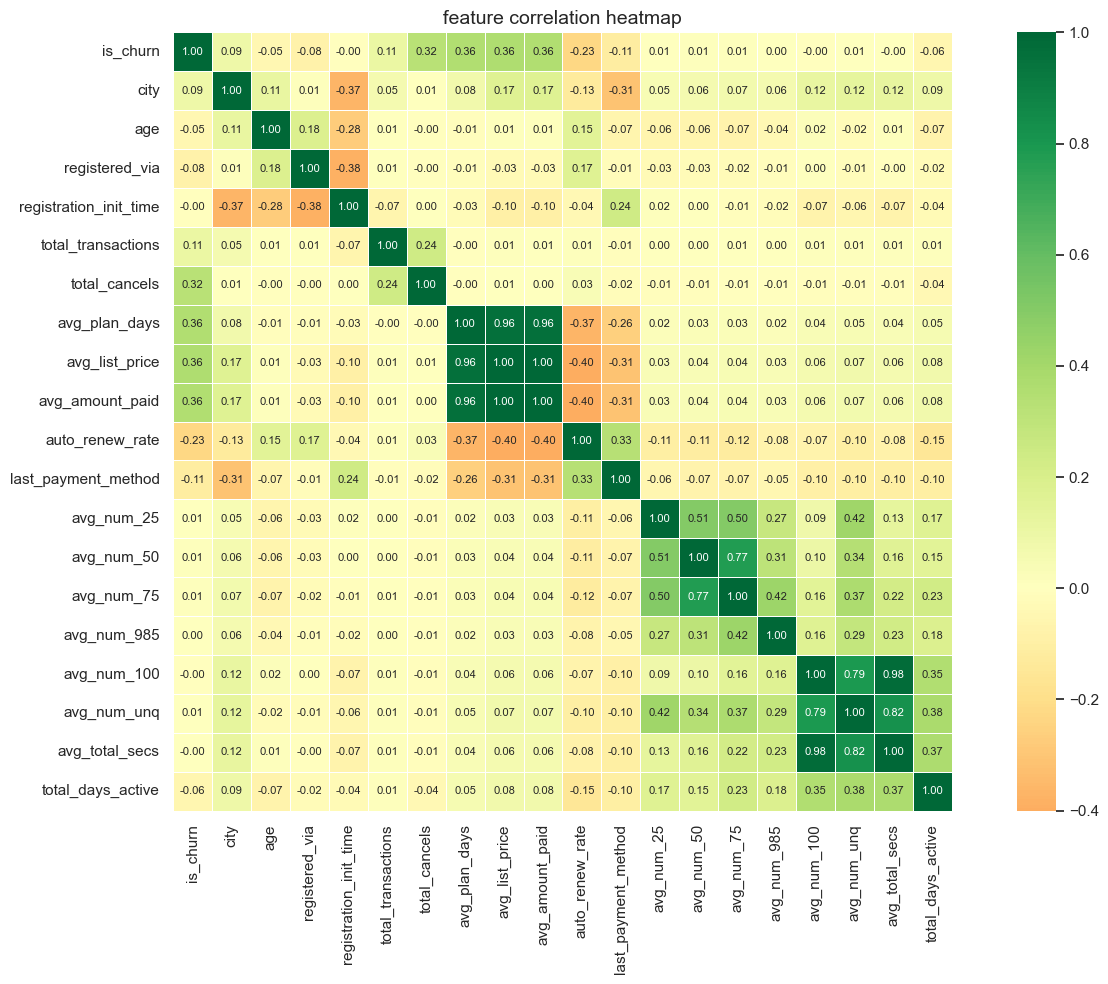

In [24]:
# correlation heatmap across all numeric features
# the is_churn row shows which features are most correlated with churn
# this helps us decide which features to prioritize in notebook 02_features.ipynb

plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('feature correlation heatmap')
plt.tight_layout()
plt.savefig('../Visualizations/plot_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

EDA Chart 8 - Do churned users log in on fewer days?

- This chart directly supports the **38% fewer active days** insight from our presentation
- `total_days_active` counts how many days (out of ~31) each user appeared in the listening logs
- A large gap here means disengagement is detectable *before* cancellation
- This became a key signal in our predictive model, later confirmed by SHAP

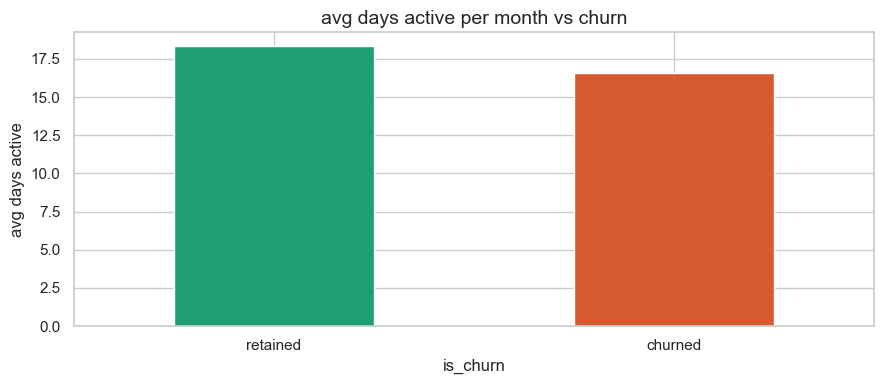

In [25]:
plt.figure(figsize=(9, 4))
df.groupby('is_churn')['total_days_active'].mean().plot(
    kind='bar', color=['#1D9E75', '#D85A30'], edgecolor='white', rot=0)
plt.title('avg days active per month vs churn')
plt.xticks([0, 1], ['retained', 'churned'])
plt.ylabel('avg days active')
plt.tight_layout()
plt.savefig('../Visualizations/plot_days_active_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

#### Final statistical summary of the full cleaned dataset

In [26]:
# describe() shows count, mean, std, min, percentiles, max for every numeric column
# useful to confirm the cleaning worked and understand feature scales before modeling

print("=== statistical summary of cleaned dataset ===\n")
print(df.describe().round(2).to_string())

=== statistical summary of cleaned dataset ===

        is_churn       city        age  registered_via  registration_init_time  total_transactions  total_cancels  avg_plan_days  avg_list_price  avg_amount_paid  auto_renew_rate  last_payment_method  avg_num_25  avg_num_50  avg_num_75  avg_num_985  avg_num_100  avg_num_unq  avg_total_secs  total_days_active
count  970960.00  970960.00  970960.00       970960.00               970960.00           970960.00      970960.00      970960.00       970960.00        970960.00        970960.00            970960.00   970960.00   970960.00   970960.00    970960.00    970960.00    970960.00       970960.00          970960.00
mean        0.09       5.38      28.76            6.90             20133549.90                1.20           0.03          33.53          144.27           143.96             0.92                38.98        4.94        1.22        0.76         0.82        23.06        23.19         6078.84              18.17
std         0.29      

#### Outlier capping and final column cleanup before export

**Why outlier capping?**  
Some listening-activity columns have extreme outlier values (e.g. `avg_num_25` max = 1710, `avg_total_secs` max = 477 913). We apply an IQR fence (1.5 × IQR) to cap values at the whisker boundaries for the behavioural numeric columns.  

**Why drop `age`?**  
- ~60 % of users have no age recorded; after median imputation the majority of the column is a synthetic constant (28) adding noise, not signal.  
- Churn is driven by behavioural features (listening, cancellation, plan) not demographics.  
- `gender` is retained for the bias analysis in `03_modeling.ipynb`.  

The result is a **21-column file** that feeds cleanly into `02_features.ipynb`.

In [27]:
# Columns that are already naturally bounded or are categorical
# IDs are excluded; we only cap the continuous behavioural features.

cap_cols = [
    'total_transactions', 'total_cancels', 'avg_plan_days',
    'avg_list_price', 'avg_amount_paid',
    'avg_num_25', 'avg_num_50', 'avg_num_75', 'avg_num_985', 'avg_num_100',
    'avg_num_unq', 'avg_total_secs', 'total_days_active'
]

for col in cap_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        print(f"skipping {col} - IQR=0 (zero-variance column)")
        continue
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)


# drop 'age' since it has too much missing data (~60 %); imputed constant
# does not help the model and adds noise.

df = df.drop(columns=['age'])

print("\nAge column dropped")
print(f"Final columns ({len(df.columns)}): {list(df.columns)}")
print(f"Final shape: {df.shape}")

skipping total_transactions - IQR=0 (zero-variance column)
skipping total_cancels - IQR=0 (zero-variance column)
skipping avg_plan_days - IQR=0 (zero-variance column)

Age column dropped
Final columns (21): ['msno', 'is_churn', 'city', 'gender', 'registered_via', 'registration_init_time', 'total_transactions', 'total_cancels', 'avg_plan_days', 'avg_list_price', 'avg_amount_paid', 'auto_renew_rate', 'last_payment_method', 'avg_num_25', 'avg_num_50', 'avg_num_75', 'avg_num_985', 'avg_num_100', 'avg_num_unq', 'avg_total_secs', 'total_days_active']
Final shape: (970960, 21)


#### Save the cleaned dataset to use in the next two notebooks:

- 02_features.ipynb will load this and engineer new columns
- 03_modeling.ipynb will load the feature version and train the model
- PowerBI will also load this csv directly for the dashboard
- index=False means we do not write the row numbers as a column

In [28]:
df.to_csv('../data/merged_datasets/merged_df.csv', index=False)
print(f"saved merged_df.csv in data/merged_datasets folder.")
print(f"shape: {df.shape}")
print(f"columns: {list(df.columns)}")
print("\nEDA completed => Run 02_features.ipynb next")

saved merged_df.csv in data/merged_datasets folder.
shape: (970960, 21)
columns: ['msno', 'is_churn', 'city', 'gender', 'registered_via', 'registration_init_time', 'total_transactions', 'total_cancels', 'avg_plan_days', 'avg_list_price', 'avg_amount_paid', 'auto_renew_rate', 'last_payment_method', 'avg_num_25', 'avg_num_50', 'avg_num_75', 'avg_num_985', 'avg_num_100', 'avg_num_unq', 'avg_total_secs', 'total_days_active']

EDA completed => Run 02_features.ipynb next
